# Super Dense Coding

Quantum Circuit


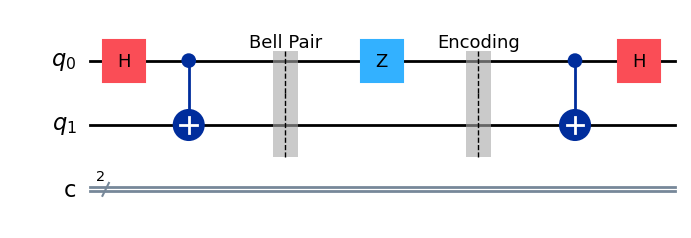

Statevector


<IPython.core.display.Latex object>

Density Matrix


<IPython.core.display.Latex object>

Bloch Sphere


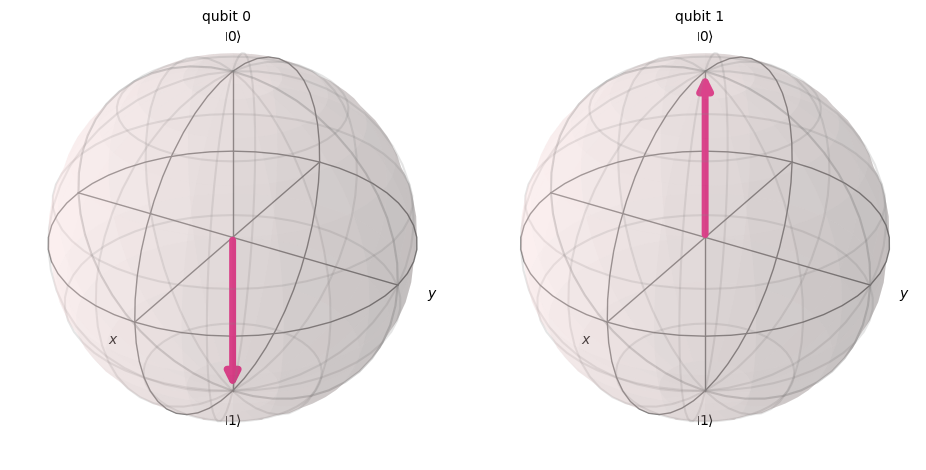

QSphere


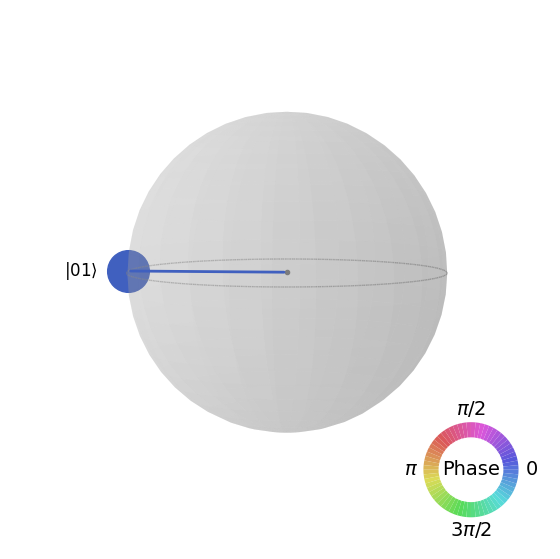

Unitary Operator


array([[0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j],
       [1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j],
       [0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j]])

Sampler Counts
{'01': 1024}

Aer Simulator Counts
{'01': 1024}
Measurement Histogram


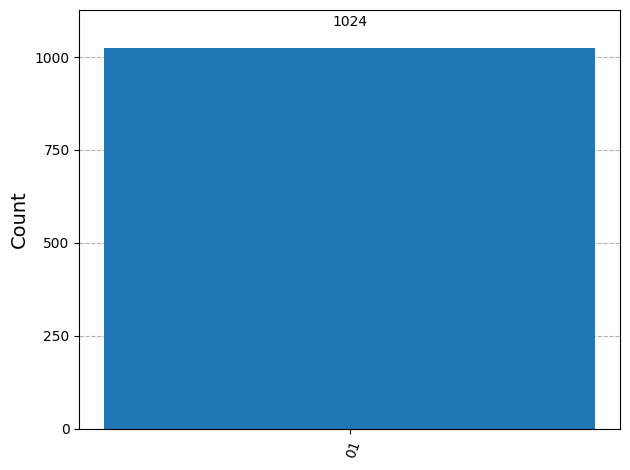

In [29]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, DensityMatrix, Operator
from qiskit.visualization import (
    plot_histogram,
    plot_bloch_multivector,
    plot_state_qsphere
)
from qiskit.primitives import StatevectorSampler
from qiskit_aer import AerSimulator
from IPython.display import display


# ---------------------------------------------------------
# Superdense Coding Circuit
# ---------------------------------------------------------
def superdense_coding(message="00"):

    qc = QuantumCircuit(2, 2)

    # -----------------------------------------------------
    # Step 1 : Create Bell Pair
    # -----------------------------------------------------
    qc.h(0)
    qc.cx(0, 1)

    qc.barrier(label="Bell Pair")

    # -----------------------------------------------------
    # Step 2 : Alice Encodes Two Classical Bits
    # -----------------------------------------------------
    if message == "00":
        pass
    elif message == "01":
        qc.x(0)
    elif message == "10":
        qc.z(0)
    elif message == "11":
        qc.z(0)
        qc.x(0)

    qc.barrier(label="Encoding")

    # -----------------------------------------------------
    # Step 3 : Bob Decodes
    # -----------------------------------------------------
    qc.cx(0, 1)
    qc.h(0)

    return qc


# =========================================================
# Choose Message
# =========================================================
message = "10"

qc = superdense_coding(message)


# =========================================================
# 1. Circuit Diagram
# =========================================================
print("Quantum Circuit")
display(qc.draw("mpl"))


# =========================================================
# 2. Statevector
# =========================================================
state = Statevector.from_instruction(qc)

print("Statevector")
display(state.draw("latex"))


# =========================================================
# 3. Density Matrix
# =========================================================
density = DensityMatrix(state)

print("Density Matrix")
display(density.draw("latex"))


# =========================================================
# 4. Bloch Sphere
# =========================================================
print("Bloch Sphere")
display(plot_bloch_multivector(state))


# =========================================================
# 5. QSphere
# =========================================================
print("QSphere")
display(plot_state_qsphere(state))


# =========================================================
# 6. Unitary Operator
# =========================================================
print("Unitary Operator")
display(Operator(qc).data)


# =========================================================
# 7. Measurement Circuit
# =========================================================
qc_measure = qc.copy()
qc_measure.measure([0, 1], [0, 1])


# =========================================================
# 8. Sampler
# =========================================================
sampler = StatevectorSampler()

job = sampler.run([qc_measure], shots=1024)

sampler_result = job.result()

sampler_counts = sampler_result[0].data.c.get_counts()

print("Sampler Counts")
print(sampler_counts)


# =========================================================
# 9. Aer Simulator
# =========================================================
simulator = AerSimulator()

result = simulator.run(qc_measure, shots=1024).result()

counts = result.get_counts()

print("\nAer Simulator Counts")
print(counts)


# =========================================================
# 10. Histogram
# =========================================================
print("Measurement Histogram")
display(plot_histogram(counts))